# Employee Attrition Prediction
**Goal:** Predict whether an employee will leave the company, identify the strongest drivers of attrition, and turn that into an HR recommendation.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle) | [LINK](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

**Stack:** Python, Pandas, scikit-learn, Matplotlib/Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

### Load the data

In [2]:
df = pd.read_csv("/Users/alejandromugica/Desktop/Personal/da/5_pj/hr_employee_attrition.csv")
print(df.shape)
df.head(5)

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
# quick check for nulls / duplicate columns / constant columns
print("Nulls per column:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nColumns with only 1 unique value (safe to drop):",
      [c for c in df.columns if df[c].nunique() == 1])

Nulls per column:
 Age                         0
StandardHours               0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
MonthlyIncome               0
dtype: int64

Columns with only 1 unique value (safe to drop): ['EmployeeCount', 'Over18', 'StandardHours']


### Exploratory data analysis
Before modeling, understand what drives attrition in the raw data. Every chart here should answer a specific question, not just exist.

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


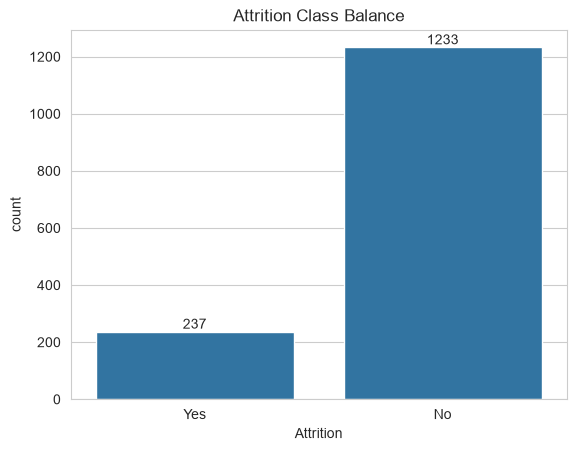

In [5]:
# overall attrition rate; establishes the class imbalance we're working with
attrition_rate = df["Attrition"].value_counts(normalize=True)
print(attrition_rate)

ax = sns.countplot(data=df, x="Attrition")
for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Attrition Class Balance")
plt.show()

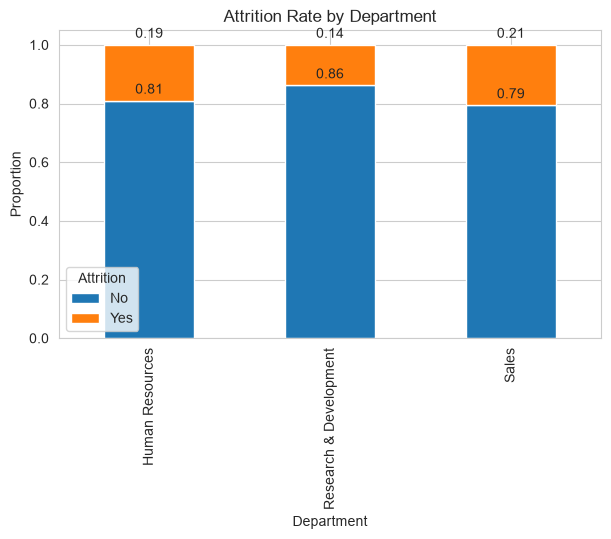

In [8]:
# attrition by department
dept_attrition = pd.crosstab(df["Department"], df["Attrition"], normalize="index")
ax = dept_attrition.plot(kind="bar", stacked=True, figsize=(7,4))
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.2f")

plt.title("Attrition Rate by Department")
plt.ylabel("Proportion")
plt.show()

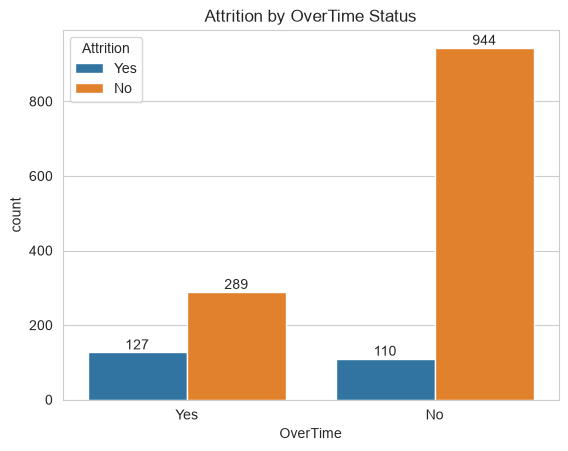

In [7]:
# attrition by overtime; one of the strongest predictors in this dataset
ax = sns.countplot(data=df, x="OverTime", hue="Attrition")
for container in ax.containers:
    ax.bar_label(container)
  
plt.title("Attrition by OverTime Status")
plt.show()

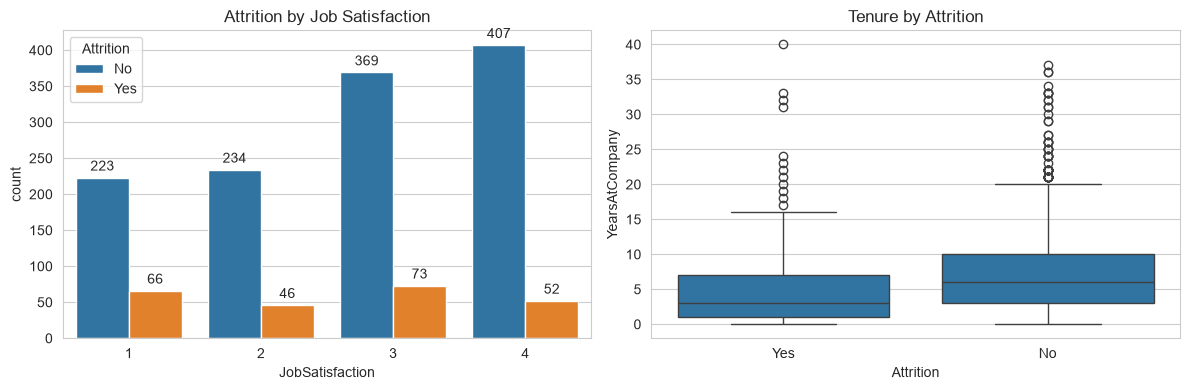

In [6]:
# attrition by job satisfaction and tenure
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", ax=axes[0])
axes[0].set_title("Attrition by Job Satisfaction")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany", ax=axes[1])
axes[1].set_title("Tenure by Attrition")
plt.tight_layout()
plt.show()

**Takeaway**

Sales had the highest attrition rate across the three departments at approximately 21%, while Research & Development retained about 86% of its employees, the highest retention rate among the departments. Overtime also showed a strong association with attrition: employees who worked overtime had an attrition rate of approximately 31%, compared with about 10% for employees who did not work overtime. Although the no-overtime group was larger overall, the overtime group had slightly more employees leave, which indicates a disproportionately higher risk of attrition among employees working overtime. Finally, employees with the lowest job-satisfaction rating had the highest attrition rate, at approximately 23%, suggesting that lower job satisfaction is associated with a greater risk of departure.

### Preprocessing
Encode categoricals, drop unhelpful columns, and split before touching the imbalance; never balance before splitting, or you leak information into the test set.

In [ ]:
# drop columns that carry no signal (constant or pure identifiers)
drop_cols = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# target
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

# encode remaining categorical columns
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols)

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_encoded.shape

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


/var/folders/z2/38r70r711b34y_s1c9nvzmk40000gn/T/ipykernel_32668/1332788175.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.tolist()


(1470, 45)

In [ ]:
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train class balance:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test class balance:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [ ]:
# scale numeric features (logistic regression is sensitive to feature scale; random forest isn't,
# but it's harmless to share the same prepped data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline model
Use `class_weight="balanced"` instead of oversampling first

In [ ]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

ROC-AUC: 0.7982599707123783


### Comparison model — Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC: 0.7769833749676975


### Evaluation

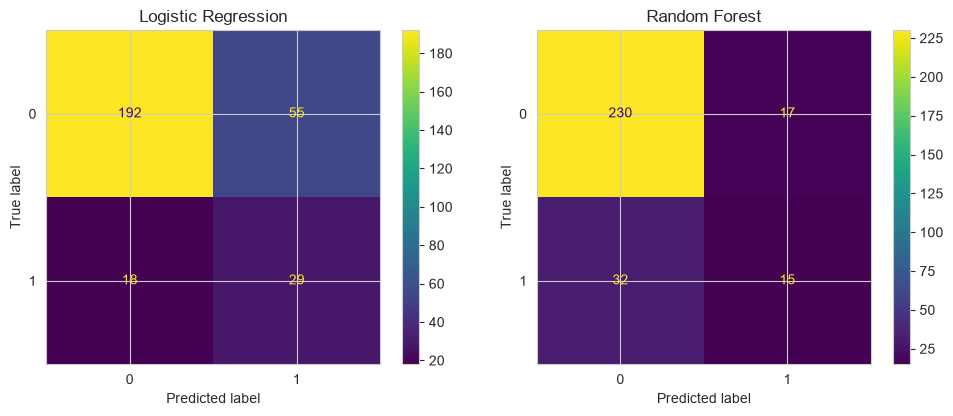

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

0 = employee stayed.
1 = employee left.

*Layout*
| | Predicted stay: 0 | Predicted leave: 1 |
| :--- | :---: | :---: |
| **Actually stayed: 0** | True negative | False positive |
| **Actually left: 1** | False negative | True positive |

---

*Logistic regression*
| | Predicted stay | Predicted leave |
| :--- | :---: | :---: |
| **Actually stayed** | 192 | 55 |
| **Actually left** | 18 | 29 |

192 true negatives: The model correctly predicted that 192 employees would stay.

55 false positives: The model predicted 55 employees would leave, but they actually stayed.

18 false negatives: The model predicted 18 employees would stay, but they actually left. These are missed attrition cases.

29 true positives: The model correctly identified 29 employees who actually left.

The logistic-regression model’s attrition recall is:

$$\text{Recall} = \frac{29}{29 + 18} = \frac{29}{47} \approx 61.7\%$$

So it finds about 62% of employees who actually left. Its attrition precision is:

$$\text{Precision} = \frac{29}{29 + 55} = \frac{29}{84} \approx 34.5\%$$

So when it flags an employee as likely to leave, about 35% actually leave. The other flagged employees are false positives.

------

*Random Forest*
| | Predicted stay | Predicted leave |
| :--- | :---: | :---: |
| **Actually stayed** | 230 | 17 |
| **Actually left** | 32 | 15 |

230 true negatives: Correctly predicted employees who stayed.

17 false positives: Incorrectly flagged employees as likely to leave.

32 false negatives: Employees who left but were missed by the model.

15 true positives: Employees who left and were correctly identified.

Its attrition recall is:

$$\text{Recall} = \frac{15}{15 + 32} = \frac{15}{47} \approx 31.9\%$$

So it identifies only about 32% of employees who actually left. Its attrition precision is:

$$\text{Precision} = \frac{15}{15 + 17} = \frac{15}{32} \approx 46.9\%$$

So when it flags an employee, it is more selective: about 47% of its flagged employees actually leave.

*In short*
The models make a different type of mistake:

Logistic regression is more sensitive. It flags more people as being at risk, so it catches more real leavers—but it also creates more false alarms.

Random forest is more conservative. It flags fewer people, so it creates fewer false alarms—but it misses many employees who later leave.

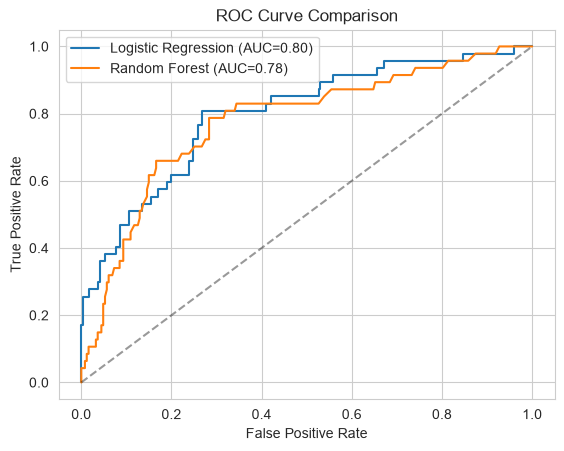

In [20]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})")
plt.plot([0,1],[0,1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

X-axis: False Positive Rate—how often the model incorrectly flags an employee who stays as likely to leave.

Y-axis: True Positive Rate, also called recall—how often the model correctly identifies employees who actually leave.

Dashed diagonal line: random guessing.

A curve closer to the upper-left corner represents better classification performance.

### Interpretation 

In [21]:
# Logistic regression coefficients (direction matters here — positive = increases attrition odds)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)

print("Top 10 features increasing attrition risk:")
print(coef_df.head(10))
print("\nTop 10 features decreasing attrition risk:")
print(coef_df.tail(10))

Top 10 features increasing attrition risk:
                             feature  coefficient
34     JobRole_Laboratory Technician     0.810172
43                      OverTime_Yes     0.771095
23  BusinessTravel_Travel_Frequently     0.722538
7                           JobLevel     0.650173
40      JobRole_Sales Representative     0.531090
24      BusinessTravel_Travel_Rarely     0.512780
21           YearsSinceLastPromotion     0.499063
26                  Department_Sales     0.470587
11                NumCompaniesWorked     0.464327
42              MaritalStatus_Single     0.455366

Top 10 features decreasing attrition risk:
                         feature  coefficient
0                            Age    -0.266981
6                 JobInvolvement    -0.285370
37     JobRole_Research Director    -0.388326
30          EducationField_Other    -0.389932
8                JobSatisfaction    -0.393219
4        EnvironmentSatisfaction    -0.434370
29        EducationField_Medical    -0.45

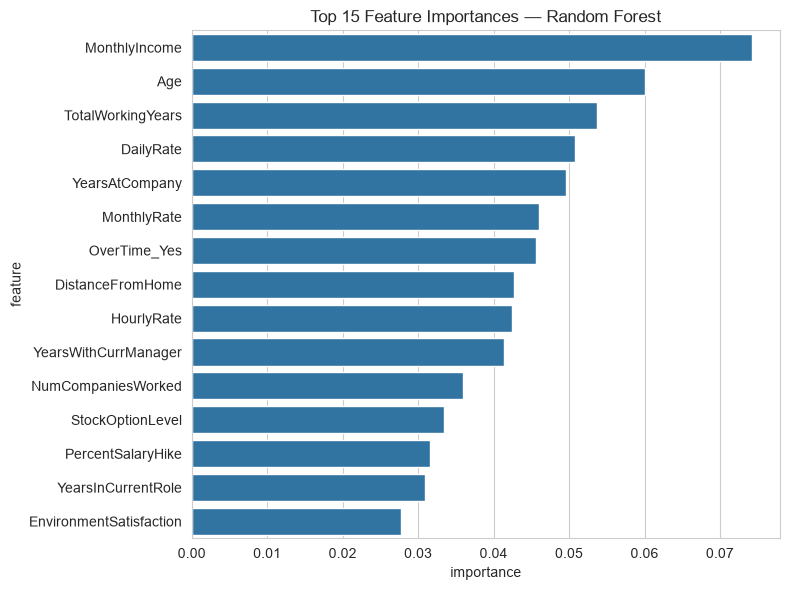

In [22]:
# Random forest feature importance (magnitude only, no direction)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()